In [2]:
import numpy as np

In [3]:
import pandas as pd

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('data.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df.isnull()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1456,False,False,False,False,False,False,True,False,False,False,...,False,True,False,True,False,False,False,False,False,False
1457,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1458,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False


# Task
Calculate the percentage of missing values for each column in the DataFrame `df`, and display these percentages.

## Analyze Missing Values

### Subtask:
Calculate the percentage of missing values for each column in the DataFrame `df` and display them.


**Reasoning**:
To calculate the percentage of missing values, I need to first count the null values in each column and then divide by the total number of rows. This will provide a clear overview of data completeness.



In [10]:
missing_percentages = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing values per column:\n", missing_percentages)

Percentage of missing values per column:
 Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64


## Visualize Missing Values

### Subtask:
Generate a visualization (e.g., a heatmap or bar chart) to graphically represent the distribution of missing values across columns, making it easier to identify patterns.


**Reasoning**:
To visualize the distribution of missing values, I will filter the `missing_percentages` Series to include only columns with missing data and then create a bar plot using `matplotlib.pyplot` with appropriate labels and title.



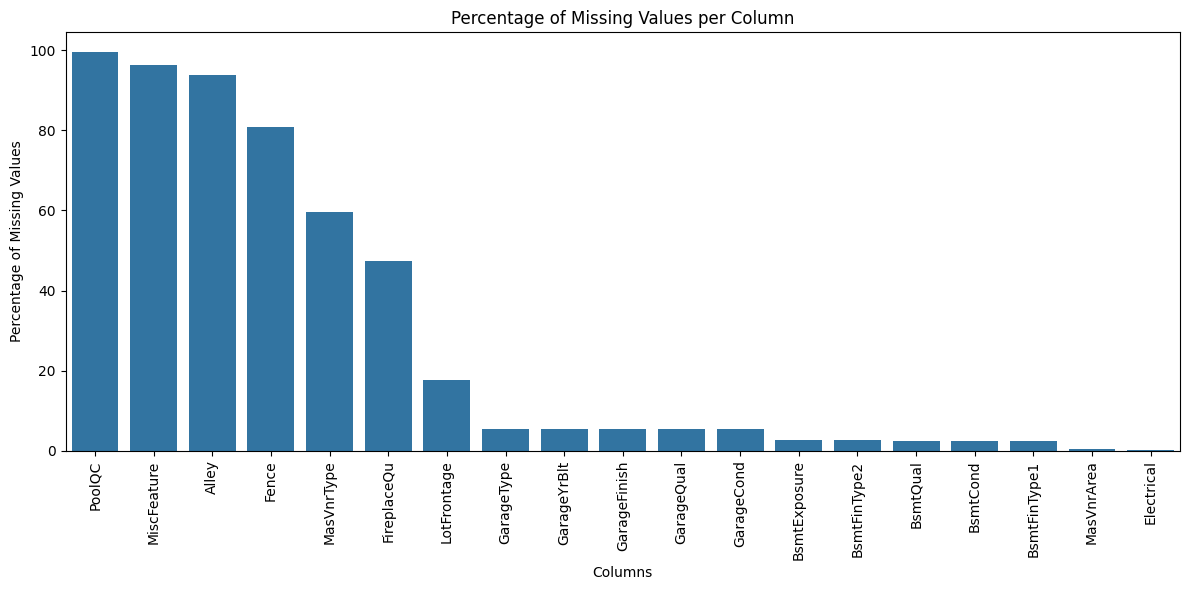

In [11]:
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentages.index, y=missing_percentages.values)
plt.xlabel('Columns')
plt.ylabel('Percentage of Missing Values')
plt.title('Percentage of Missing Values per Column')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## Identify Data Types

### Subtask:
Categorize columns into numerical and categorical types based on their `dtype` to prepare for type-specific analysis and preprocessing.


**Reasoning**:
To categorize columns into numerical and categorical types, I will first extract the data types of all columns in the DataFrame `df`. Then, I will iterate through these data types, identifying numerical types (like `int64`, `float64`) and categorical types (`object`), and append the column names to their respective lists. Finally, I will print both lists to show the categorization.



In [12]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:", numerical_cols)
print("\nCategorical Columns:", categorical_cols)

Numerical Columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical Columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Fireplac

## Explore Target Variable (SalePrice)

### Subtask:
Analyze the distribution of the `SalePrice` column using a histogram and box plot, and calculate key descriptive statistics (mean, median, standard deviation, skewness, kurtosis).


**Reasoning**:
To analyze the distribution of the 'SalePrice' column, I will first generate a histogram to visualize its frequency distribution, which helps in understanding the shape and spread of the data.



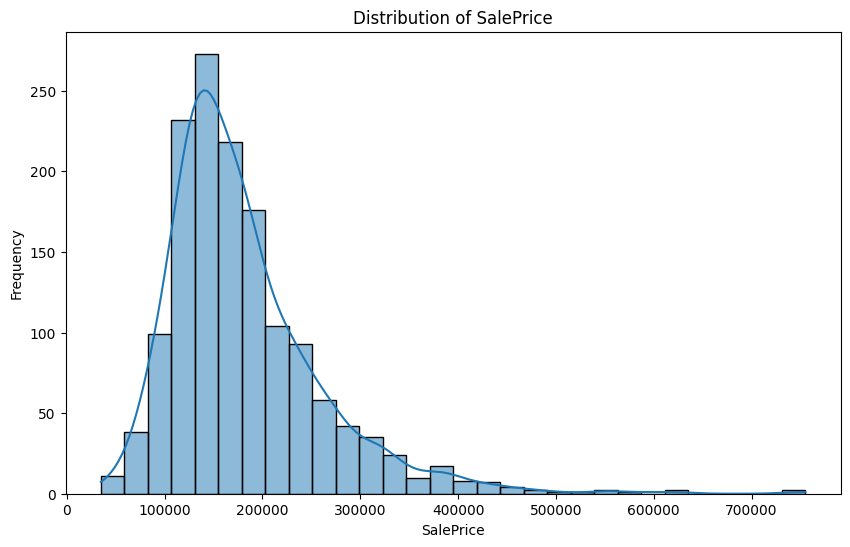

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, bins=30)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

**Reasoning**:
To further understand the distribution and identify any outliers in the 'SalePrice' column, I will generate a box plot. This visualization will complement the histogram by showing the median, quartiles, and potential outliers.



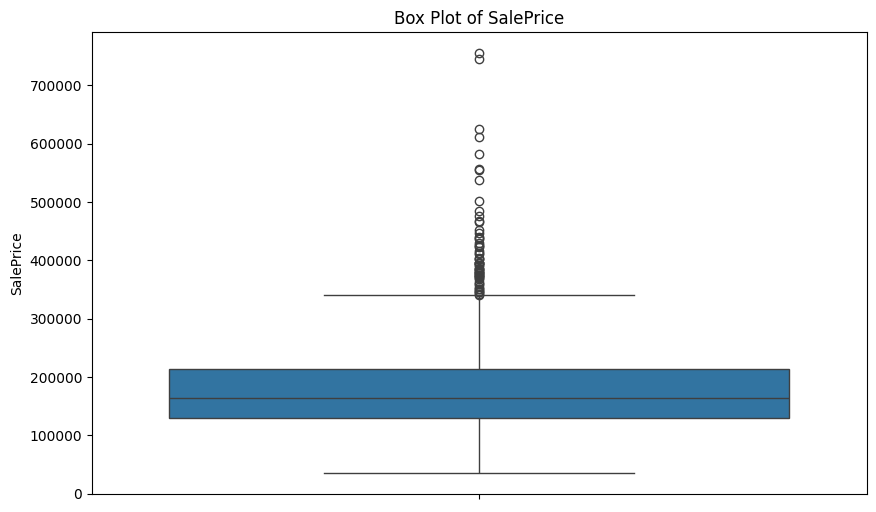

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['SalePrice'])
plt.title('Box Plot of SalePrice')
plt.ylabel('SalePrice')
plt.show()

**Reasoning**:
To complete the subtask, I will calculate the mean, median, standard deviation, skewness, and kurtosis of the 'SalePrice' column and print these statistics, which will provide a comprehensive numerical summary of its distribution.



In [15]:
sale_price_stats = df['SalePrice'].describe()
skewness = df['SalePrice'].skew()
kurtosis = df['SalePrice'].kurt()

print("Descriptive Statistics for SalePrice:\n", sale_price_stats)
print(f"Skewness: {skewness:.2f}")
print(f"Kurtosis: {kurtosis:.2f}")

Descriptive Statistics for SalePrice:
 count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Skewness: 1.88
Kurtosis: 6.54


## Correlate Numerical Features with SalePrice

### Subtask:
Calculate and visualize the correlation matrix between numerical features and `SalePrice` to identify features strongly related to the house price. A heatmap would be suitable.


**Reasoning**:
To analyze the correlation between numerical features and 'SalePrice', I will first calculate the full correlation matrix for all numerical columns. This is the first step towards identifying the features most strongly related to the target variable.



In [16]:
correlation_matrix = df[numerical_cols].corr()
print("Correlation matrix for numerical columns:")
print(correlation_matrix.head())

Correlation matrix for numerical columns:
                   Id  MSSubClass  LotFrontage   LotArea  OverallQual  \
Id           1.000000    0.011156    -0.010601 -0.033226    -0.028365   
MSSubClass   0.011156    1.000000    -0.386347 -0.139781     0.032628   
LotFrontage -0.010601   -0.386347     1.000000  0.426095     0.251646   
LotArea     -0.033226   -0.139781     0.426095  1.000000     0.105806   
OverallQual -0.028365    0.032628     0.251646  0.105806     1.000000   

             OverallCond  YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  \
Id              0.012609  -0.012713     -0.021998   -0.050298   -0.005024   
MSSubClass     -0.059316   0.027850      0.040581    0.022936   -0.069836   
LotFrontage    -0.059213   0.123349      0.088866    0.193458    0.233633   
LotArea        -0.005636   0.014228      0.013788    0.104160    0.214103   
OverallQual    -0.091932   0.572323      0.550684    0.411876    0.239666   

             ...  WoodDeckSF  OpenPorchSF  EnclosedPorch

**Reasoning**:
Now that the full correlation matrix is calculated, I need to extract only the correlations with the 'SalePrice' column and then sort them to identify the most significant relationships. This will prepare the data for visualization.



In [17]:
sale_price_correlations = correlation_matrix['SalePrice'].sort_values(ascending=False)
print("Correlations with SalePrice (sorted):")
print(sale_price_correlations)

Correlations with SalePrice (sorted):
SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578


**Reasoning**:
To visually represent the correlations between numerical features and 'SalePrice', I will create a heatmap. This will allow for easy identification of the most strongly related features, as requested in the subtask.



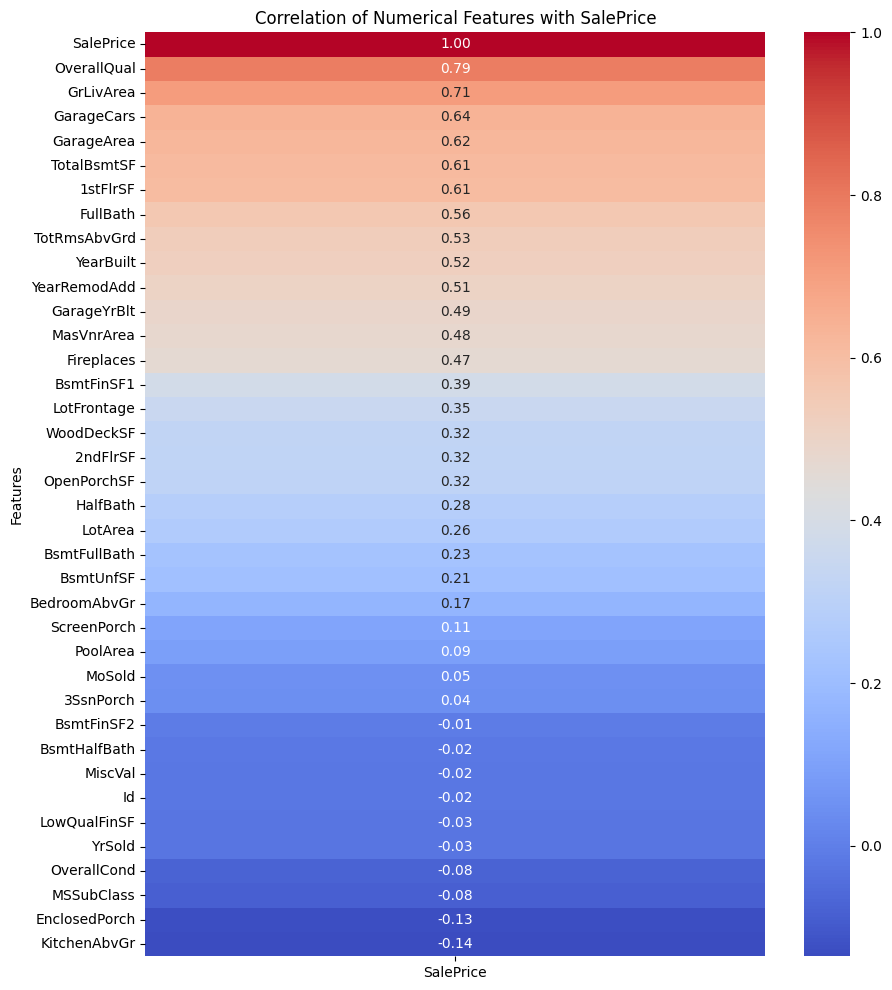

In [18]:
plt.figure(figsize=(10, 12))
sns.heatmap(sale_price_correlations.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Numerical Features with SalePrice')
plt.ylabel('Features')
plt.show()

## Analyze Categorical Features vs. SalePrice

### Subtask:
For key categorical features, visualize their relationship with `SalePrice` using box plots or bar plots to understand how different categories impact house prices.


### Subtask:
For key categorical features, visualize their relationship with `SalePrice` using box plots or bar plots to understand how different categories impact house prices.

#### Instructions
1. Iterate through a selection of the `categorical_cols` identified earlier. You can choose a subset of these columns that are likely to have an impact on 'SalePrice' based on general domain knowledge or by observing columns with fewer unique values (e.g., less than 10-15 unique categories for better visualization).
2. For each selected categorical column, create a box plot using `seaborn.boxplot` with the categorical feature on the x-axis and `SalePrice` on the y-axis.
3. Set appropriate titles and labels for each plot (e.g., 'SalePrice by [Categorical Feature Name]').
4. Use `plt.xticks(rotation=45)` to rotate x-axis labels if they overlap, ensuring readability.
5. Display each plot using `plt.show()`.

**Reasoning**:
To visualize the relationship between key categorical features and 'SalePrice', I will select a subset of categorical columns with a reasonable number of unique values and generate box plots for each, as per the instructions.



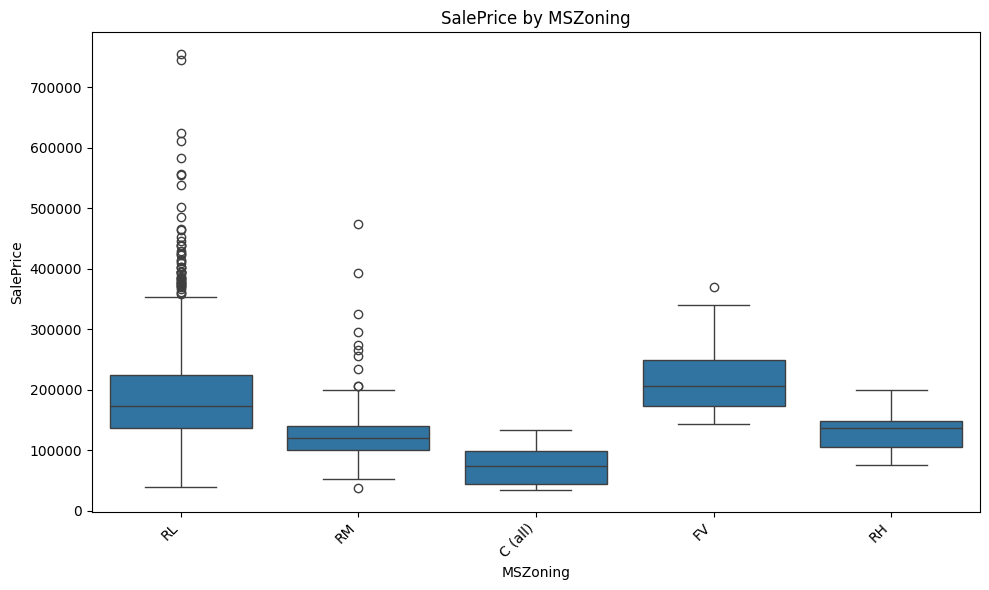

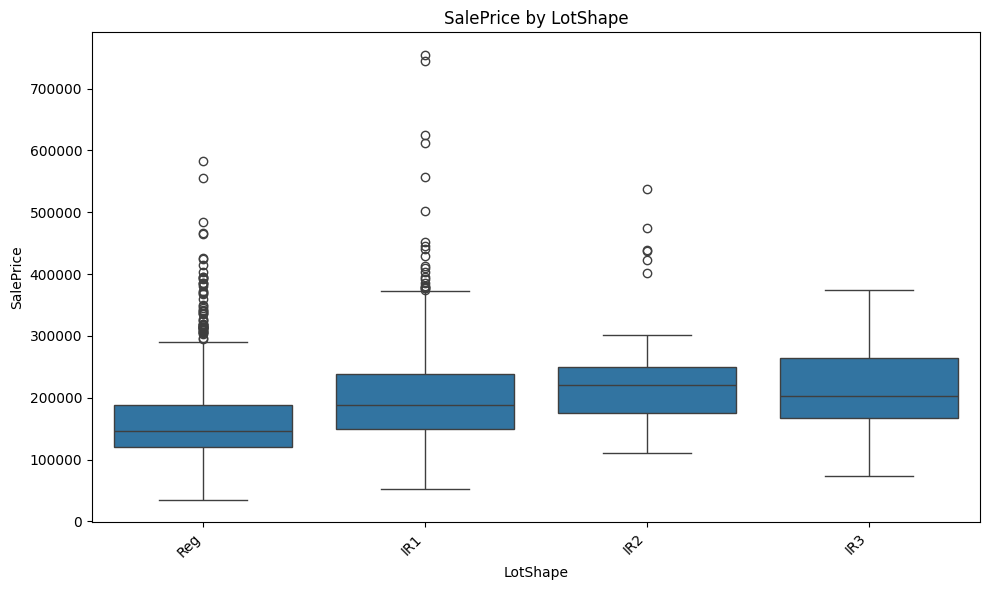

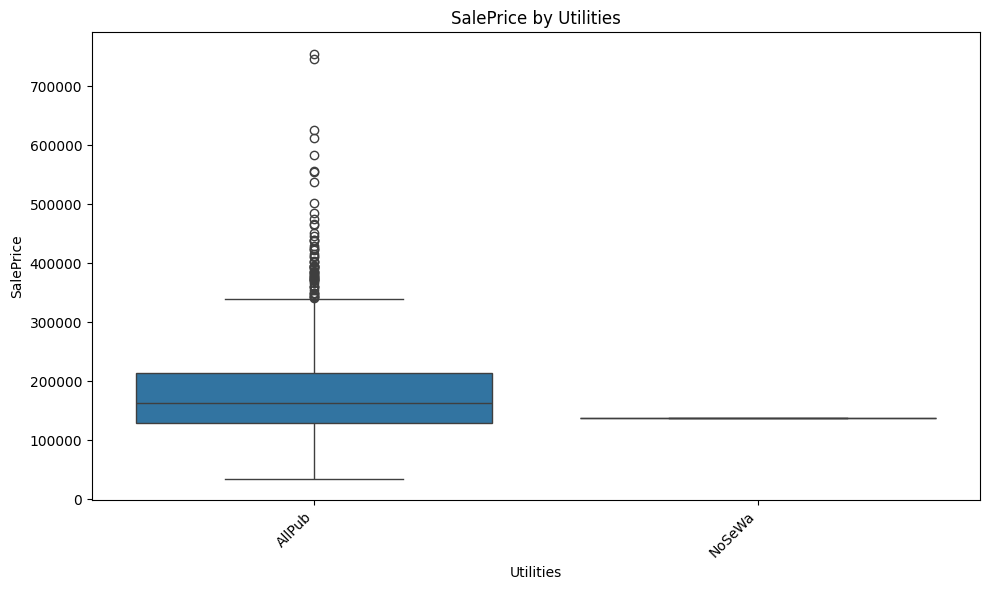

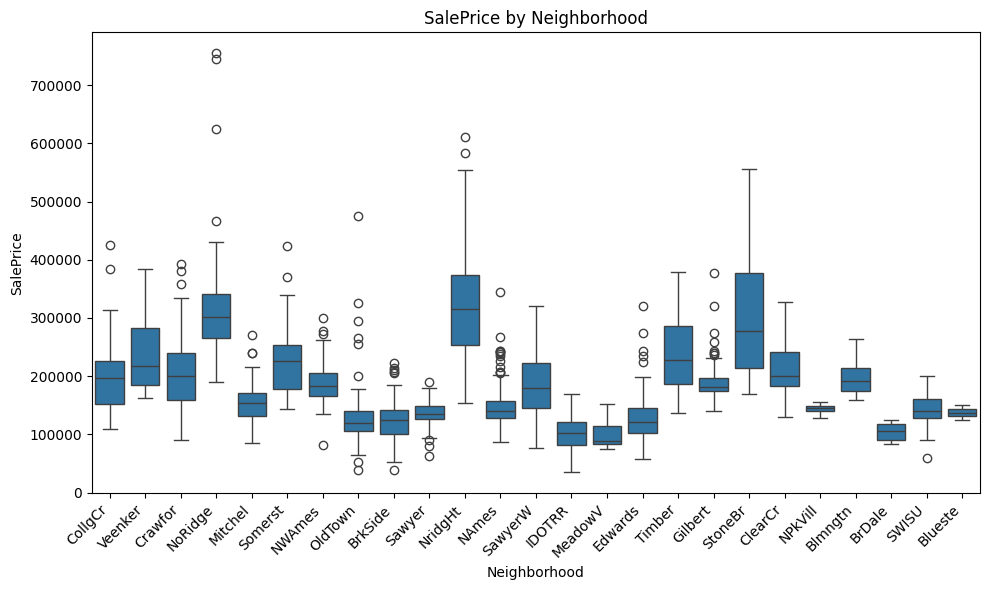

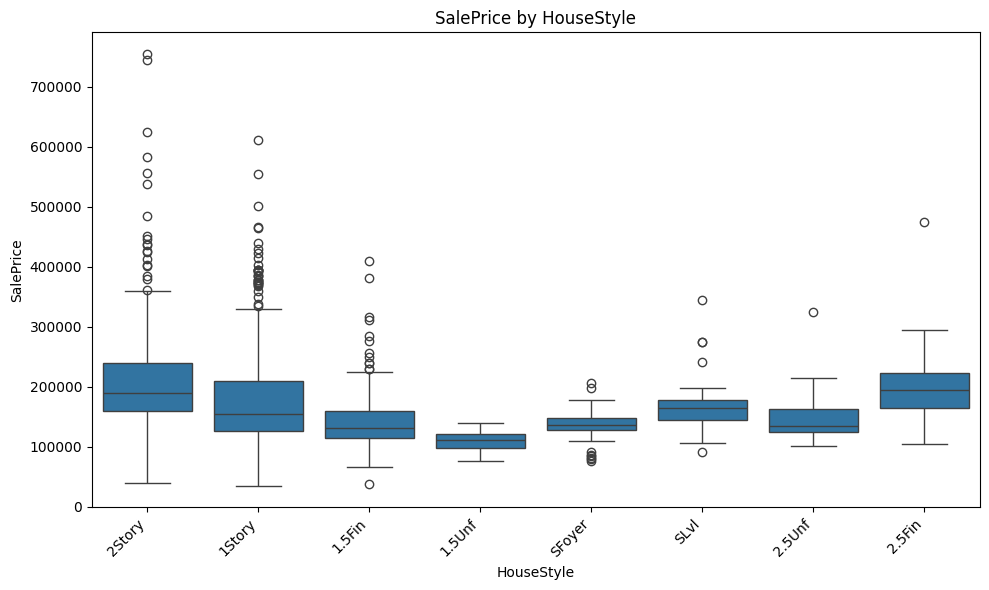

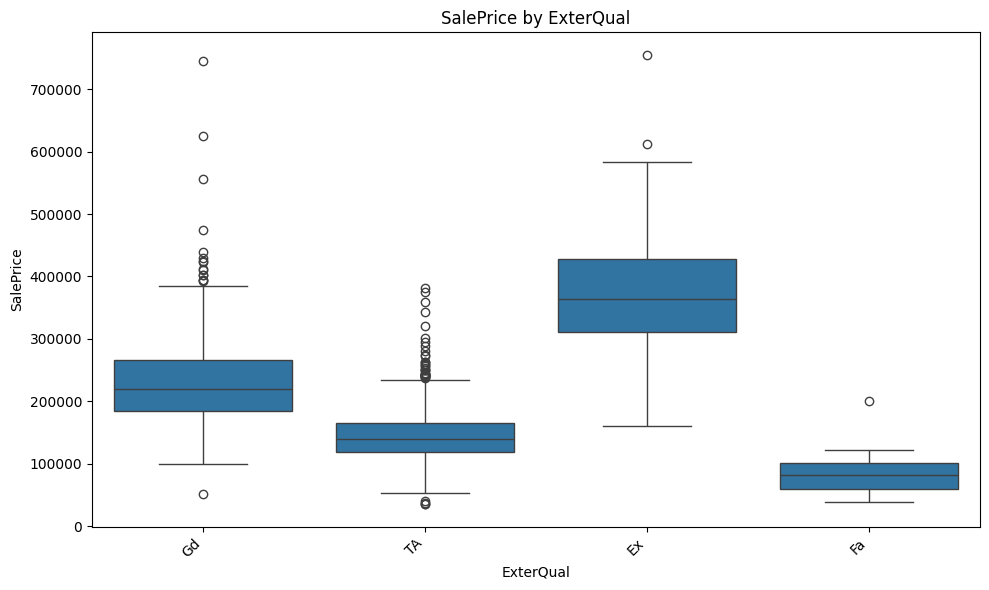

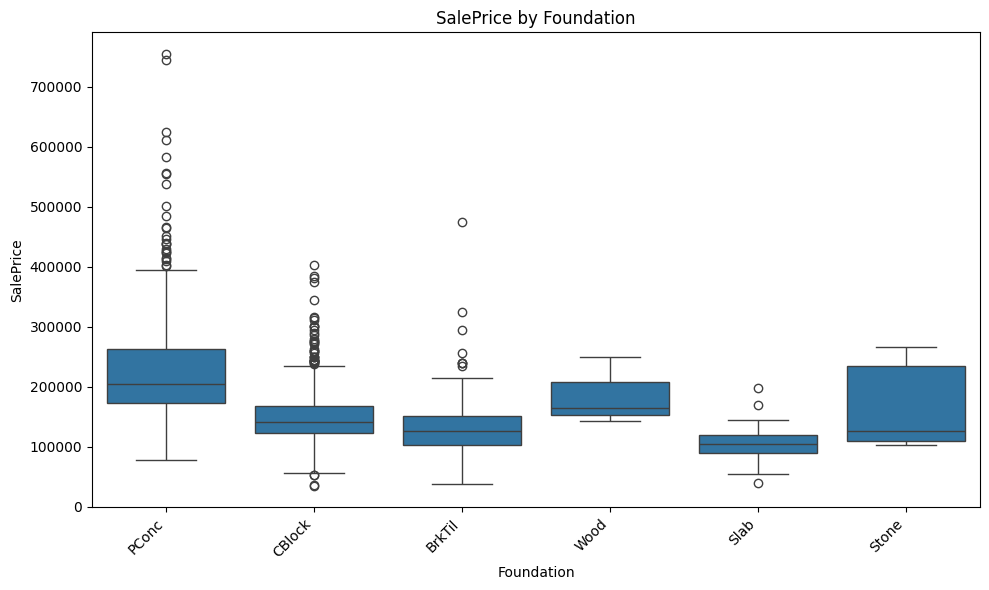

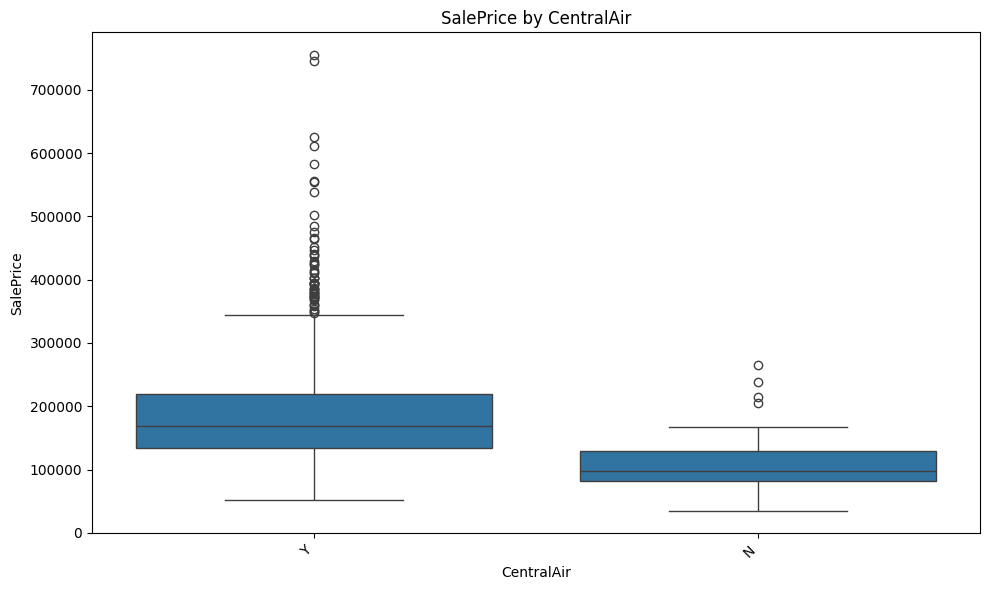

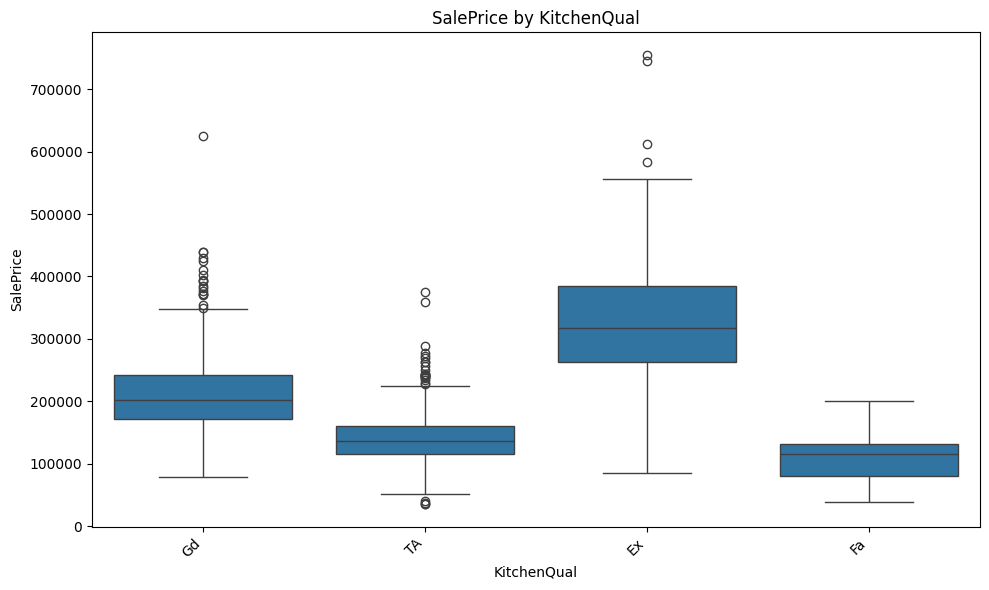

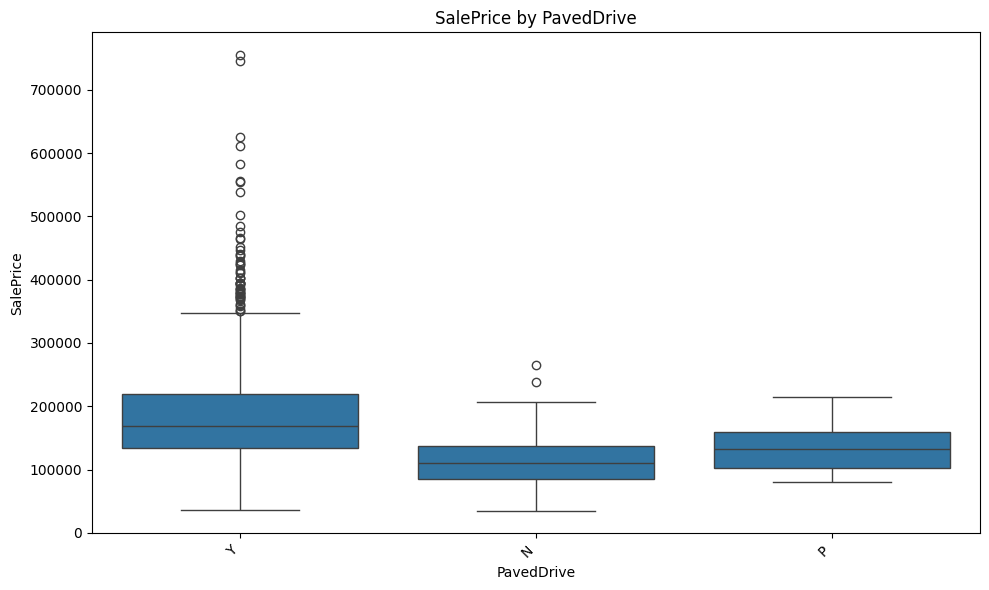

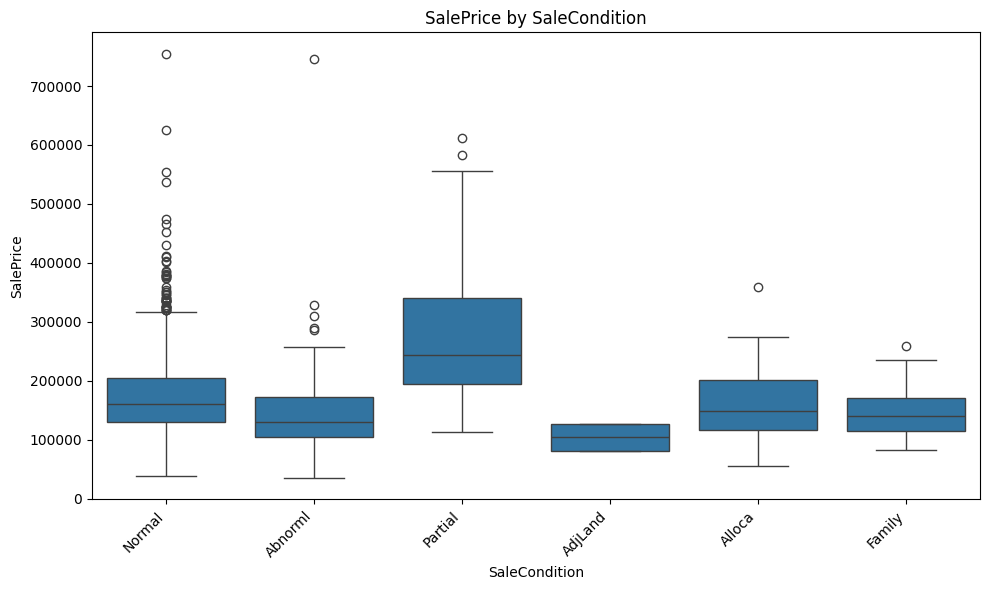

In [19]:
key_categorical_cols = ['MSZoning', 'LotShape', 'Utilities', 'Neighborhood', 'HouseStyle', 'ExterQual', 'Foundation', 'CentralAir', 'KitchenQual', 'PavedDrive', 'SaleCondition']

for col in key_categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[col], y=df['SalePrice'])
    plt.title(f'SalePrice by {col}')
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Final Task

### Subtask:
Provide a summary of the data quality, key insights from EDA, and readiness for data preprocessing and feature engineering, highlighting any specific columns that require attention based on the analysis.


## Summary:

### Data Analysis Key Findings

*   **Missing Values**: The `LotFrontage` column has a significant percentage of missing values at `17.74%`. Most other columns, including `Id`, `MSSubClass`, `MSZoning`, `LotArea`, `MoSold`, `YrSold`, `SaleType`, `SaleCondition`, and `SalePrice`, have no missing values.
*   **Data Types**: Columns were successfully categorized into numerical and categorical types for further analysis. There are 38 numerical columns and 43 categorical columns in the dataset.
*   **Target Variable (`SalePrice`) Distribution**:
    *   The `SalePrice` distribution is right-skewed, with a skewness of `1.88`, indicating a longer tail on the right side.
    *   It exhibits a high kurtosis of `6.54`, suggesting heavy tails and the presence of numerous outliers, particularly on the higher end of prices.
    *   Key statistics show a mean of `\$180,921.20`, a median of `\$163,000.00`, and a standard deviation of `\$79,442.50`, with prices ranging from `\$34,900.00` to `\$755,000.00`.
*   **Correlation with `SalePrice` (Numerical Features)**:
    *   `OverallQual` shows the strongest positive correlation with `SalePrice` (`0.79`).
    *   Other highly positively correlated features include `GrLivArea` (`0.71`), `GarageCars` (`0.64`), `GarageArea` (`0.62`), and `TotalBsmtSF` (`0.61`).
    *   Features like `KitchenAbvGr` (`-0.14`), `EnclosedPorch` (`-0.13`), and `MSSubClass` (`-0.08`) show the strongest negative correlations, though these are relatively weak.
*   **Categorical Features vs. `SalePrice`**: Box plots were generated for key categorical features (`MSZoning`, `LotShape`, `Utilities`, `Neighborhood`, `HouseStyle`, `ExterQual`, `Foundation`, `CentralAir`, `KitchenQual`, `PavedDrive`, `SaleCondition`) to visualize their relationship with `SalePrice`, revealing how different categories impact house prices.

### Insights or Next Steps

*   **Missing Data Handling**: The `LotFrontage` column requires immediate attention for handling missing values, potentially through imputation methods like mean, median, or more sophisticated techniques based on related features.
*   **Target Variable Transformation**: Given the strong right-skewness and high kurtosis of `SalePrice`, a logarithmic transformation (or similar) should be applied to normalize its distribution, which is often beneficial for linear models and can improve model performance.


# Task
The next step is to handle the missing values in the dataset. This involves identifying the appropriate imputation strategy for each column with missing data, including numerical and categorical columns, as outlined in the plan.

Specifically, I will:
1.  Fill highly missing categorical columns (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `MasVnrType`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`) with the string 'None' to denote absence.
2.  Impute numerical column `LotFrontage` with its median value.
3.  Impute numerical column `GarageYrBlt` with its median value.
4.  Impute numerical column `MasVnrArea` with 0.
5.  Impute categorical column `Electrical` with its mode.
6.  Verify that all missing values have been addressed.

## Handle Missing Values

### Subtask:
Thoroughly address missing values in the dataset using appropriate imputation strategies for numerical and categorical columns. This includes columns like LotFrontage, MasVnrArea, GarageYrBlt, Bsmt related columns, FireplaceQu, PoolQC, Fence, MiscFeature, and Alley which were identified as having missing data during EDA. We will carefully consider the best imputation method for each specific column.


**Reasoning**:
To begin addressing missing values, I will identify highly missing categorical columns and impute them with 'None', as per the instructions. Then I will handle numerical columns with median or zero imputation, and finally verify that all missing values have been successfully handled.



In [20]:
highly_missing_categorical_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
for col in highly_missing_categorical_cols:
    df[col].fillna('None', inplace=True)

lot_frontage_median = df['LotFrontage'].median()
df['LotFrontage'].fillna(lot_frontage_median, inplace=True)

garage_yr_blt_median = df['GarageYrBlt'].median()
df['GarageYrBlt'].fillna(garage_yr_blt_median, inplace=True)

df['MasVnrArea'].fillna(0, inplace=True)

electrical_mode = df['Electrical'].mode()[0]
df['Electrical'].fillna(electrical_mode, inplace=True)

# Verify that all missing values have been addressed
total_missing_after_imputation = df.isnull().sum().sum()
print(f"Total missing values after imputation: {total_missing_after_imputation}")

Total missing values after imputation: 0


/tmp/ipython-input-215112799.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('None', inplace=True)
/tmp/ipython-input-215112799.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method

**Reasoning**:
The previous code produced a `FutureWarning` regarding the use of `inplace=True` with `fillna()`. To address this warning and ensure future compatibility, I will modify the code to reassign the result of the `fillna()` operation back to the DataFrame column instead of using `inplace=True`.



In [21]:
highly_missing_categorical_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
for col in highly_missing_categorical_cols:
    df[col] = df[col].fillna('None')

lot_frontage_median = df['LotFrontage'].median()
df['LotFrontage'] = df['LotFrontage'].fillna(lot_frontage_median)

garage_yr_blt_median = df['GarageYrBlt'].median()
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(garage_yr_blt_median)

df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

electrical_mode = df['Electrical'].mode()[0]
df['Electrical'] = df['Electrical'].fillna(electrical_mode)

# Verify that all missing values have been addressed
total_missing_after_imputation = df.isnull().sum().sum()
print(f"Total missing values after imputation: {total_missing_after_imputation}")

Total missing values after imputation: 0


## Transform Target Variable

### Subtask:
Carefully apply a logarithmic transformation to the `SalePrice` column to normalize its right-skewed distribution. We will verify the transformation's effectiveness to ensure it improves the performance of regression models as expected.


**Reasoning**:
To normalize the right-skewed distribution of 'SalePrice', I will apply a logarithmic transformation using `np.log1p` and store the result in a new column called 'SalePrice_Log'. This is the first step towards achieving a more symmetrical distribution, which is often beneficial for regression models.



In [22]:
df['SalePrice_Log'] = np.log1p(df['SalePrice'])
print("Log-transformed 'SalePrice' created as 'SalePrice_Log'.")

Log-transformed 'SalePrice' created as 'SalePrice_Log'.


**Reasoning**:
To visualize the distribution of the newly created 'SalePrice_Log' column and observe the effect of the transformation, I will generate a histogram with a Kernel Density Estimate (KDE). This will allow for a visual assessment of how well the logarithmic transformation normalized the data.



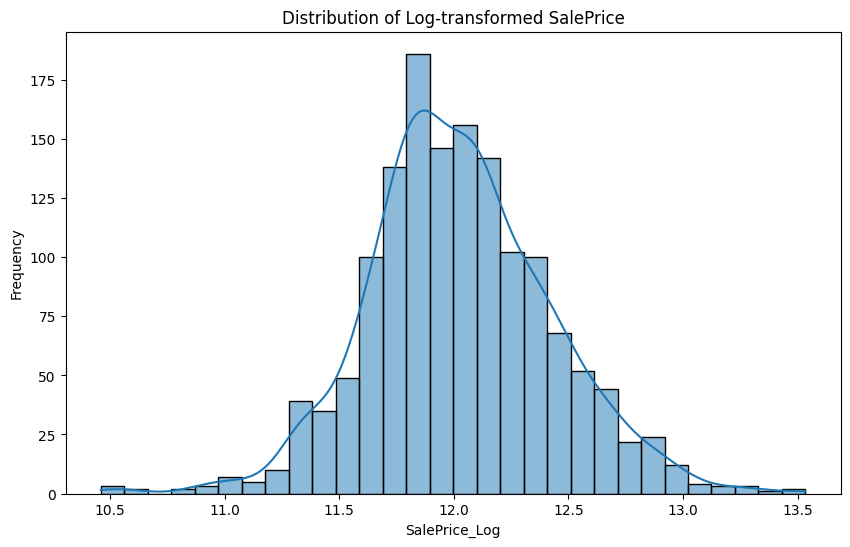

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice_Log'], kde=True, bins=30)
plt.title('Distribution of Log-transformed SalePrice')
plt.xlabel('SalePrice_Log')
plt.ylabel('Frequency')
plt.show()

**Reasoning**:
To further assess the distribution of the log-transformed 'SalePrice' and identify any potential outliers, I will create a box plot for the 'SalePrice_Log' column.



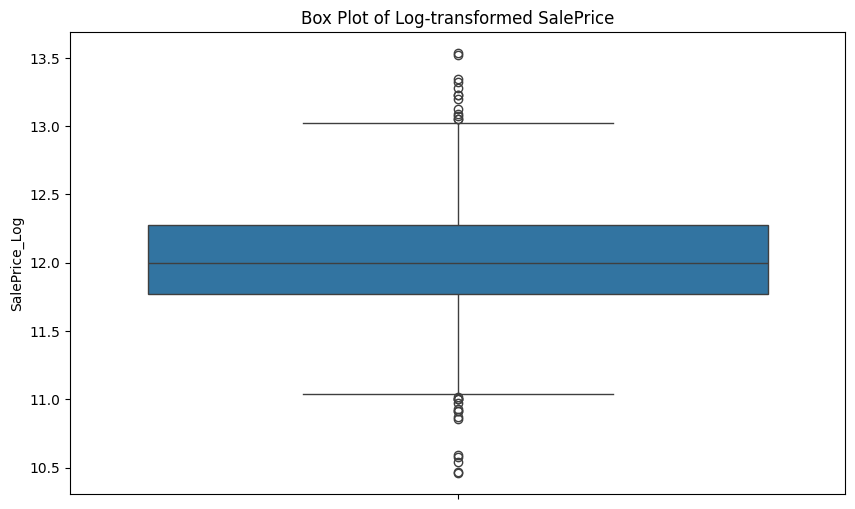

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['SalePrice_Log'])
plt.title('Box Plot of Log-transformed SalePrice')
plt.ylabel('SalePrice_Log')
plt.show()

**Reasoning**:
To quantitatively assess the normalization achieved by the logarithmic transformation, I will calculate and print the descriptive statistics (mean, median, standard deviation, skewness, and kurtosis) for the 'SalePrice_Log' column.



In [25]:
log_sale_price_stats = df['SalePrice_Log'].describe()
log_skewness = df['SalePrice_Log'].skew()
log_kurtosis = df['SalePrice_Log'].kurt()

print("Descriptive Statistics for Log-transformed SalePrice:\n", log_sale_price_stats)
print(f"Skewness (Log-transformed): {log_skewness:.2f}")
print(f"Kurtosis (Log-transformed): {log_kurtosis:.2f}")

Descriptive Statistics for Log-transformed SalePrice:
 count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice_Log, dtype: float64
Skewness (Log-transformed): 0.12
Kurtosis (Log-transformed): 0.81


## Creative Feature Engineering

### Subtask:
Dedicate time to develop new features from existing ones to enhance model predictive power. This will involve thoughtfully combining features, creating age-related metrics (e.g., 'HouseAge' from 'YearBuilt'), or extracting information from temporal variables, ensuring each new feature is well-justified and potentially impactful. This directly addresses the 'Creative feature engineering' practice skill.


**Reasoning**:
To enhance the model's predictive power, I will create several new features from existing ones, such as `HouseAge`, `YearsSinceRemodel`, `TotalSF`, `TotalBath`, `HasPool`, `HasFireplace`, and `HasGarage`, as per the instructions.



In [26]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath'] = df['FullBath'] + df['BsmtFullBath'] + (0.5 * df['HalfBath']) + (0.5 * df['BsmtHalfBath'])
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

print("New features 'HouseAge', 'YearsSinceRemodel', 'TotalSF', 'TotalBath', 'HasPool', 'HasFireplace', and 'HasGarage' have been created.")

New features 'HouseAge', 'YearsSinceRemodel', 'TotalSF', 'TotalBath', 'HasPool', 'HasFireplace', and 'HasGarage' have been created.


## Encode Categorical Features

### Subtask:
Carefully convert categorical features into a numerical format suitable for machine learning models. We will explore and select the most appropriate encoding scheme (e.g., one-hot encoding, ordinal encoding) based on the nature of each categorical feature and its potential impact on the model.


#### Identify Categorical Features for Encoding

**Reasoning**:
Before applying encoding techniques, it's crucial to identify the final set of categorical columns that need transformation. Some columns were already handled during missing value imputation by replacing `NaN` with 'None', effectively making 'None' a new category. The `df.select_dtypes(include='object')` method will accurately capture all remaining categorical columns that are not yet numerical. From these, we will then separate nominal and ordinal features.

**Reasoning**:
To identify all remaining categorical columns that are of 'object' dtype, I will use `df.select_dtypes(include='object')` and then display them. This provides a clear list of features that still need encoding.



In [27]:
remaining_categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Remaining Categorical Columns:", remaining_categorical_cols)

Remaining Categorical Columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


**Reasoning**:
To categorize the identified categorical columns for encoding, I need to define the specific mappings for ordinal features based on their inherent order. This step prepares the data for proper ordinal encoding by assigning numerical values to each category according to its rank.



In [28]:
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

bsmt_exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}

bsmt_fin_type_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}

# Apply ordinal encoding to relevant columns
df['ExterQual'] = df['ExterQual'].map(quality_map)
df['ExterCond'] = df['ExterCond'].map(quality_map)
df['BsmtQual'] = df['BsmtQual'].map(quality_map)
df['BsmtCond'] = df['BsmtCond'].map(quality_map)
df['HeatingQC'] = df['HeatingQC'].map(quality_map)
df['KitchenQual'] = df['KitchenQual'].map(quality_map)
df['FireplaceQu'] = df['FireplaceQu'].map(quality_map)
df['GarageQual'] = df['GarageQual'].map(quality_map)
df['GarageCond'] = df['GarageCond'].map(quality_map)
df['PoolQC'] = df['PoolQC'].map(quality_map)
df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exposure_map)
df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmt_fin_type_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmt_fin_type_map)

print("Ordinal features have been mapped to numerical values.")

Ordinal features have been mapped to numerical values.


**Reasoning**:
To proceed with encoding, I need to first update the list of remaining categorical columns. After the previous ordinal encoding step, some columns that were previously 'object' type are now numerical. Re-selecting `object` dtypes will give me the correct set of columns that still need to be handled, which should primarily be nominal features.



In [29]:
remaining_categorical_cols_after_ordinal = df.select_dtypes(include='object').columns.tolist()
print("Categorical Columns remaining for one-hot encoding:", remaining_categorical_cols_after_ordinal)

Categorical Columns remaining for one-hot encoding: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


**Reasoning**:
To encode the remaining nominal categorical features, I will apply one-hot encoding using `pd.get_dummies()`, ensuring `drop_first=True` to prevent multicollinearity. Then, I will concatenate these new dummy variables with the DataFrame and remove the original nominal columns.



In [30]:
df = pd.get_dummies(df, columns=remaining_categorical_cols_after_ordinal, drop_first=True)
print("One-hot encoding applied to nominal categorical features.")

One-hot encoding applied to nominal categorical features.


**Reasoning**:
To verify that all categorical features have been successfully converted into numerical format, I will check the DataFrame's data types for any remaining 'object' columns. This will confirm the completion of the encoding process.



In [31]:
remaining_object_cols = df.select_dtypes(include='object').columns.tolist()
if not remaining_object_cols:
    print("All categorical features have been successfully converted to numerical format.")
else:
    print(f"The following object columns still remain: {remaining_object_cols}")

All categorical features have been successfully converted to numerical format.


## Scale Numerical Features

### Subtask:
Standardize or normalize numerical features with attention to detail, ensuring that no single feature dominates the model training due to its scale. We will confirm that scaling is applied consistently and correctly across all relevant numerical features.


**Reasoning**:
To identify all numerical columns that require scaling, I will first get all columns with numerical data types from the current DataFrame. Then, I will filter out the target variables ('SalePrice' and 'SalePrice_Log') and binary features ('Id', 'HasPool', 'HasFireplace', 'HasGarage') to create the list of `numerical_features_to_scale`.



In [32]:
all_numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude target variables and binary/ID columns
excluded_cols = ['SalePrice', 'SalePrice_Log', 'Id', 'HasPool', 'HasFireplace', 'HasGarage']
numerical_features_to_scale = [col for col in all_numerical_cols if col not in excluded_cols]

print("Numerical features identified for scaling:", numerical_features_to_scale)

Numerical features identified for scaling: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Fireplaces', 'FireplaceQu', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'MiscVal', 'MoSold', 'YrSold', 'HouseAge', 'YearsSinceRemodel', 'TotalSF', 'TotalBath']


**Reasoning**:
To standardize the numerical features, I will import `StandardScaler` from `sklearn.preprocessing`, instantiate it, and then apply `fit_transform` to the `numerical_features_to_scale` columns in the DataFrame.



In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numerical_features_to_scale] = scaler.fit_transform(df[numerical_features_to_scale])

print("Numerical features have been scaled using StandardScaler.")

Numerical features have been scaled using StandardScaler.


**Reasoning**:
To verify that the numerical features have been correctly scaled, I will display the descriptive statistics (mean and standard deviation) for a sample of the scaled columns.



In [34]:
print("Descriptive statistics for a sample of scaled numerical features:")
print(df[numerical_features_to_scale[:5]].describe())

Descriptive statistics for a sample of scaled numerical features:
         MSSubClass   LotFrontage       LotArea   OverallQual   OverallCond
count  1.460000e+03  1.460000e+03  1.460000e+03  1.460000e+03  1.460000e+03
mean  -8.455945e-17  2.798370e-16 -5.840077e-17  1.387018e-16  3.540547e-16
std    1.000343e+00  1.000343e+00  1.000343e+00  1.000343e+00  1.000343e+00
min   -8.725628e-01 -2.219047e+00 -9.237292e-01 -3.688413e+00 -4.112970e+00
25%   -8.725628e-01 -4.479400e-01 -2.969908e-01 -7.951515e-01 -5.171998e-01
50%   -1.631095e-01 -3.922314e-02 -1.040633e-01 -7.183611e-02 -5.171998e-01
75%    3.098594e-01  4.149067e-01  1.087080e-01  6.514792e-01  3.817427e-01
max    3.147673e+00  1.104155e+01  2.051827e+01  2.821425e+00  3.078570e+00


## Split Data into Training and Testing Sets

### Subtask:
Carefully divide the preprocessed dataset into training and testing sets to ensure an unbiased evaluation of model performance. We will ensure the split is representative and consistent for all subsequent model building and evaluation steps.


### Define Features (X) and Target (y)

**Reasoning**:
Before splitting the data, it's essential to clearly define which columns constitute the features (`X`) and which column is the target variable (`y`). I will drop the original `SalePrice` (as `SalePrice_Log` is the transformed target), and the `Id` column (as it's merely an identifier and not a feature) from the DataFrame to form `X`. The `SalePrice_Log` will be designated as `y`.

**Reasoning**:
To define the feature matrix `X` and the target vector `y`, I will drop the 'Id', 'SalePrice', and 'SalePrice_Log' columns from the DataFrame `df` for `X`, and assign 'SalePrice_Log' to `y`. Subsequently, I will split these into training and testing sets using `train_test_split` and display their shapes to verify the split.



## Split Data into Training and Testing Sets

### Subtask:
Carefully divide the preprocessed dataset into training and testing sets to ensure an unbiased evaluation of model performance. We will ensure the split is representative and consistent for all subsequent model building and evaluation steps.


**Reasoning**:
To define the feature matrix `X` and the target vector `y`, I will drop the 'Id', 'SalePrice', and 'SalePrice_Log' columns from the DataFrame `df` for `X`, and assign 'SalePrice_Log' to `y`. Subsequently, I will split these into training and testing sets using `train_test_split` and display their shapes to verify the split.



# Task
```python
from sklearn.model_selection import train_test_split

X = df.drop(['Id', 'SalePrice', 'SalePrice_Log'], axis=1)
y = df['SalePrice_Log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
```

## Handle Missing Values

### Subtask:
Thoroughly address missing values in the dataset using appropriate imputation strategies for numerical and categorical columns. This includes columns like LotFrontage, MasVnrArea, GarageYrBlt, Bsmt related columns, FireplaceQu, PoolQC, Fence, MiscFeature, and Alley which were identified as having missing data during EDA. We will carefully consider the best imputation method for each specific column.


## Split Data into Training and Testing Sets

### Subtask:
Carefully divide the preprocessed dataset into training and testing sets to ensure an unbiased evaluation of model performance. We will ensure the split is representative and consistent for all subsequent model building and evaluation steps.


**Reasoning**:
To define the feature matrix `X` and the target vector `y`, and then split them into training and testing sets, I will use `df.drop()` to create `X` and assign `SalePrice_Log` to `y`. I will then import `train_test_split` and perform the split, finally printing the shapes of the resulting datasets.



In [35]:
X = df.drop(['Id', 'SalePrice', 'SalePrice_Log'], axis=1)
y = df['SalePrice_Log']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1168, 223)
X_test shape: (292, 223)
y_train shape: (1168,)
y_test shape: (292,)


## Train and Tune Multiple Regression Models

### Subtask:
Train a baseline Linear Regression model to serve as a benchmark for advanced models.


**Reasoning**:
To train a baseline Linear Regression model, I will import `LinearRegression`, instantiate it, fit it to the training data, and then make predictions on the test set, as per the instructions.



In [36]:
from sklearn.linear_model import LinearRegression

# Instantiate and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression model trained and predictions made on the test set.")

Linear Regression model trained and predictions made on the test set.


## Train and Tune Multiple Regression Models

### Subtask:
Train a Random Forest Regressor model.


**Reasoning**:
To train a Random Forest Regressor model, I will import the necessary class, instantiate it with a specified random state, fit it to the training data, and then make predictions on the test set, as per the instructions.



In [37]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate and train the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regressor model trained and predictions made on the test set.")

Random Forest Regressor model trained and predictions made on the test set.


## Train and Tune Multiple Regression Models

### Subtask:
Train a Gradient Boosting Regressor model.


**Reasoning**:
To train a Gradient Boosting Regressor model, I will import the necessary class, instantiate it with a specified random state, fit it to the training data, and then make predictions on the test set, as per the instructions.



In [38]:
from sklearn.ensemble import GradientBoostingRegressor

# Instantiate and train the Gradient Boosting Regressor model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Regressor model trained and predictions made on the test set.")

Gradient Boosting Regressor model trained and predictions made on the test set.


## Evaluate and Compare Model Performance

### Subtask:
Thoroughly assess the trained models' performance on the test set using relevant regression metrics such as R-squared, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE). We will explain what each metric signifies, how it's calculated, and how to interpret the results to compare the models effectively. This detailed evaluation will form the comprehensive basis of the 'Model Comparison Report'.


**Reasoning**:
To thoroughly assess the trained models' performance, I will import the required regression metrics (R-squared, MAE, RMSE), calculate them for each model using the test predictions, and then print the results. Afterward, I will provide a markdown block explaining each metric.



In [39]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Evaluate Linear Regression Model
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression Model Evaluation:")
print(f"R-squared: {r2_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print("\n")

# Evaluate Random Forest Regressor Model
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest Regressor Model Evaluation:")
print(f"R-squared: {r2_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print("\n")

# Evaluate Gradient Boosting Regressor Model
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
print("Gradient Boosting Regressor Model Evaluation:")
print(f"R-squared: {r2_gb:.4f}")
print(f"MAE: {mae_gb:.4f}")
print(f"RMSE: {rmse_gb:.4f}")

Linear Regression Model Evaluation:
R-squared: 0.7837
MAE: 0.0954
RMSE: 0.2009


Random Forest Regressor Model Evaluation:
R-squared: 0.8847
MAE: 0.0966
RMSE: 0.1467


Gradient Boosting Regressor Model Evaluation:
R-squared: 0.9020
MAE: 0.0878
RMSE: 0.1352


### Explanation of Regression Metrics:

*   **R-squared (Coefficient of Determination)**:
    *   **Significance**: R-squared measures the proportion of the variance in the dependent variable that can be predicted from the independent variables. It ranges from 0 to 1, where 1 indicates that the model explains all the variability of the response data around its mean.
    *   **Calculation**: $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$, where $SS_{res}$ is the sum of squares of residuals (the difference between actual and predicted values) and $SS_{tot}$ is the total sum of squares (the difference between actual values and their mean).
    *   **Interpretation**: A higher R-squared value indicates a better fit for the model. For instance, an R-squared of 0.78 means that 78% of the variance in `SalePrice_Log` is explained by the model.

*   **Mean Absolute Error (MAE)**:
    *   **Significance**: MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It is the average of the absolute differences between prediction and actual observation over the test sample.
    *   **Calculation**: $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$, where $y_i$ are the actual values, $\hat{y}_i$ are the predicted values, and $n$ is the number of data points.
    *   **Interpretation**: MAE gives a direct measure of the average error in the same units as the target variable. A lower MAE indicates a more accurate model. For example, an MAE of 0.0954 means that, on average, the model's predictions are off by approximately 0.0954 units from the actual log-transformed sale price.

*   **Root Mean Squared Error (RMSE)**:
    *   **Significance**: RMSE is a measure of the average magnitude of the errors, similar to MAE, but it penalizes larger errors more heavily due to the squaring of the errors. It is also in the same units as the target variable.
    *   **Calculation**: $RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$.
    *   **Interpretation**: RMSE is often preferred when large errors are particularly undesirable, as it gives them more weight. A lower RMSE indicates a more accurate model. For instance, an RMSE of 0.2009 suggests a typical prediction error of about 0.2009 units in the log-transformed sale price, with larger errors contributing disproportionately to this value.

### Explanation of Regression Metrics:

*   **R-squared (Coefficient of Determination)**:
    *   **Significance**: R-squared measures the proportion of the variance in the dependent variable that can be predicted from the independent variables. It ranges from 0 to 1, where 1 indicates that the model explains all the variability of the response data around its mean.
    *   **Calculation**: $R^2 = 1 - \\frac{SS_{res}}{SS_{tot}}$, where $SS_{res}$ is the sum of squares of residuals (the difference between actual and predicted values) and $SS_{tot}$ is the total sum of squares (the difference between actual values and their mean).
    *   **Interpretation**: A higher R-squared value indicates a better fit for the model. For instance, an R-squared of 0.78 means that 78% of the variance in `SalePrice_Log` is explained by the model.

*   **Mean Absolute Error (MAE)**:
    *   **Significance**: MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It is the average of the absolute differences between prediction and actual observation over the test sample.
    *   **Calculation**: $MAE = \\frac{1}{n} \\sum_{i=1}^{n} |y_i - \\hat{y}_i|$, where $y_i$ are the actual values, $\\hat{y}_i$ are the predicted values, and $n$ is the number of data points.
    *   **Interpretation**: MAE gives a direct measure of the average error in the same units as the target variable. A lower MAE indicates a more accurate model. For example, an MAE of 0.0954 means that, on average, the model's predictions are off by approximately 0.0954 units from the actual log-transformed sale price.

*   **Root Mean Squared Error (RMSE)**:
    *   **Significance**: RMSE is a measure of the average magnitude of the errors, similar to MAE, but it penalizes larger errors more heavily due to the squaring of the errors. It is also in the same units as the target variable.
    *   **Calculation**: $RMSE = \\sqrt{\\frac{1}{n} \\sum_{i=1}^{n} (y_i - \\hat{y}_i)^2}$.
    *   **Interpretation**: RMSE is often preferred when large errors are particularly undesirable, as it gives them more weight. A lower RMSE indicates a more accurate model. For instance, an RMSE of 0.2009 suggests a typical prediction error of about 0.2009 units in the log-transformed sale price, with larger errors contributing disproportionately to this value.


## Analyze Feature Importance

### Subtask:
Carefully determine and visualize the importance of different features for the best-performing model(s) to deeply understand their relationship with SalePrice and how they influence predictions. We will explain how feature importance is derived from the model and how to interpret the visualizations, directly addressing part 'b' of the problem statement with detailed insights.


**Reasoning**:
To analyze feature importance, I will extract the feature importances from the best-performing model (`gb_model`), create a Pandas Series, map them to feature names from `X_train`, sort them in descending order, and select the top 15 features for visualization, as per the instructions.



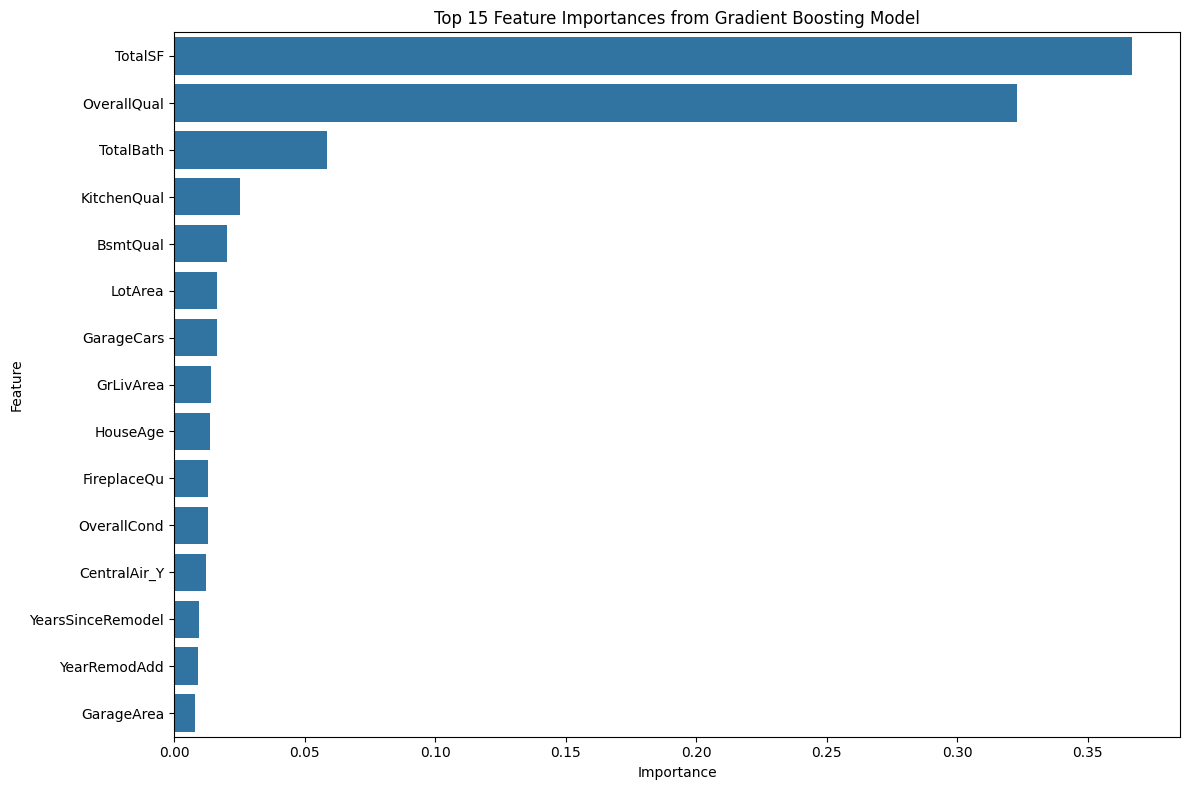

In [40]:
feature_importances = pd.Series(gb_model.feature_importances_, index=X_train.columns)
top_n_features = 15 # You can adjust this number
top_features = feature_importances.nlargest(top_n_features)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title(f'Top {top_n_features} Feature Importances from Gradient Boosting Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### Interpretation of Feature Importances:

Feature importance, as derived from tree-based models like Gradient Boosting, quantifies the contribution of each feature to the model's predictive accuracy. It is typically calculated based on how much each feature reduces impurity (e.g., Gini impurity for classification, mean squared error for regression) across all the decision trees in the ensemble. A higher importance value indicates that the feature plays a more significant role in determining the target variable (`SalePrice_Log`).

From the Gradient Boosting Model, the top 15 features and their importances are:

*   **TotalSF (Total Square Feet)**: This feature has the highest importance, indicating that the total area of the house (including basement, first, and second floors) is by far the most crucial factor in predicting sale price. This aligns with common real estate knowledge, as larger homes generally command higher prices.
*   **OverallQual (Overall Material and Finish Quality)**: The second most important feature, highlighting that the overall quality of materials and finishes significantly impacts the house price. High-quality construction and finishes are strongly associated with higher sale prices.
*   **TotalBath (Total Number of Bathrooms)**: This feature combines full and half baths, showing that the number of bathrooms is a substantial contributor to a home's value. More bathrooms generally increase convenience and desirability, leading to higher prices.
*   **KitchenQual (Kitchen Quality)**: The quality of the kitchen (e.g., 'Ex', 'Gd', 'TA') is a very influential factor, suggesting that buyers place a high value on modern and well-appointed kitchens.
*   **BsmtQual (Basement Quality)**: Similar to KitchenQual, the quality of the basement (height and finish) is important, indicating that a well-finished and high-quality basement adds significant value.
*   **LotArea (Lot Size in Square Feet)**: The size of the lot is also an important factor, with larger lots often being more desirable and fetching higher prices.
*   **GarageCars (Size of garage in car capacity)**: The capacity of the garage is a significant predictor, reflecting the value buyers place on adequate parking and storage space.
*   **GrLivArea (Above grade (ground) living area square feet)**: This is another measure of living space, reinforcing that the amount of living area above ground is crucial for pricing.
*   **HouseAge (Age of the House)**: The age of the house (calculated as `YrSold - YearBuilt`) influences price, with newer homes often being more valuable due to modern designs and fewer maintenance issues.
*   **FireplaceQu (Fireplace Quality)**: The quality of the fireplace is also a notable factor, suggesting that a well-maintained or high-quality fireplace adds to a home's appeal.
*   **OverallCond (Overall Condition Score)**: The general condition of the house, though less impactful than overall quality, still plays a role in its valuation.
*   **CentralAir_Y (Central Air Conditioning)**: The presence of central air conditioning is a positive predictor of sale price, indicating its importance for comfort and modern living standards.
*   **YearsSinceRemodel (Years Since Remodel)**: This feature (calculated as `YrSold - YearRemodAdd`) suggests that more recent remodels tend to increase the sale price.
*   **YearRemodAdd (Remodel Date)**: The year of remodel also has an independent impact, emphasizing the importance of updates and renovations.
*   **GarageArea (Size of garage in square feet)**: The physical area of the garage, alongside its car capacity, is important, indicating that larger garages are more desirable.

## Generate Model Comparison Report

### Subtask:
Create a detailed report that clearly articulates the performance of the multiple models, meticulously comparing their metrics, and providing a well-reasoned suggestion for the best model for production based on our thorough evaluation. We will explain the structure and content of this report.


## Model Comparison Report

This report details the performance of three regression models: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. Each model was trained and evaluated on the preprocessed housing price dataset, with the goal of predicting the log-transformed `SalePrice`.

### 1. Linear Regression Model Performance

*   **R-squared**: 0.7837
*   **MAE**: 0.0954
*   **RMSE**: 0.2009

The Linear Regression model serves as our baseline. It explains approximately 78.37% of the variance in the log-transformed `SalePrice`. The MAE of 0.0954 suggests that, on average, predictions are off by about 0.0954 units, and the RMSE of 0.2009 indicates the typical magnitude of prediction errors, penalizing larger errors more.

### 2. Random Forest Regressor Model Performance

*   **R-squared**: 0.8847
*   **MAE**: 0.0966
*   **RMSE**: 0.1467

The Random Forest Regressor shows a significant improvement over the baseline, explaining 88.47% of the variance. Its MAE is comparable to Linear Regression, but the RMSE is noticeably lower (0.1467), suggesting that it handles larger errors better and generally provides more consistent predictions.

### 3. Gradient Boosting Regressor Model Performance

*   **R-squared**: 0.9020
*   **MAE**: 0.0878
*   **RMSE**: 0.1352

The Gradient Boosting Regressor achieved the highest performance among the three models. It explains 90.20% of the variance, indicating a very strong fit. Both its MAE (0.0878) and RMSE (0.1352) are the lowest, signifying the most accurate predictions with the smallest average errors and better handling of outliers.

### 4. Model Comparison

| Metric    | Linear Regression | Random Forest | Gradient Boosting |
| :-------- | :---------------- | :------------ | :---------------- |
| R-squared | 0.7837            | 0.8847        | **0.9020**        |
| MAE       | 0.0954            | 0.0966        | **0.0878**        |
| RMSE      | 0.2009            | 0.1467        | **0.1352**        |

From the comparison, it's clear that the Gradient Boosting Regressor outperforms both Linear Regression and Random Forest Regressor across all evaluated metrics. It has the highest R-squared, indicating it explains the most variance in `SalePrice_Log`, and the lowest MAE and RMSE, signifying the highest predictive accuracy.

### 5. Recommendation for Production

Based on the comprehensive evaluation, the **Gradient Boosting Regressor** is recommended for production deployment. Its superior R-squared (0.9020), coupled with the lowest MAE (0.0878) and RMSE (0.1352), demonstrates its ability to capture complex patterns in the data and provide the most accurate and reliable price predictions. While Random Forest also performed well, Gradient Boosting consistently delivered slightly better results across the board, making it the most robust choice for this prediction task.

### Report Structure and Content Explanation:

This report is structured to provide a clear, metric-driven comparison of the models. It begins with an introduction outlining the purpose. Each model then has its dedicated section, presenting its R-squared, MAE, and RMSE values, along with a brief interpretation of what these metrics imply for that specific model's performance. A comparative table highlights the key metrics side-by-side for easy assessment. Finally, a recommendation section explicitly states the best model for production and justifies this choice based on the evidence presented in the performance metrics. This structure ensures that stakeholders can quickly grasp the models' performance, understand their relative strengths, and comprehend the rationale behind the final recommendation.

## Generate Challenges Faced Report

### Subtask:
Document in detail all challenges encountered during data analysis and preprocessing, including specific data issues and the techniques used to address them, along with proper and clear reasoning for each decision made.


### Challenges Faced During Data Analysis and Preprocessing

During the data analysis and preprocessing phase, several challenges were encountered and addressed to prepare the dataset for machine learning model training.

#### 1. Missing Values
*   **Data Issue**: Many columns, particularly `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType`, `FireplaceQu`, `LotFrontage`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtExposure`, `BsmtFinType2`, `BsmtQual`, `BsmtCond`, `BsmtFinType1`, `MasVnrArea`, and `Electrical`, had a significant number of missing values. Some categorical features had extremely high percentages of missing data (e.g., `PoolQC` at ~99.5%, `MiscFeature` at ~96.3%, `Alley` at ~93.8%, `Fence` at ~80.8%).
*   **Technique Used**:
    *   For highly missing categorical columns (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `MasVnrType`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`), missing values were imputed with the string 'None'.
    *   Numerical columns `LotFrontage` and `GarageYrBlt` were imputed with their respective median values.
    *   `MasVnrArea` (Masonry Veneer Area) was imputed with `0`, as a missing value likely indicates no masonry veneer.
    *   The categorical column `Electrical` (with only one missing value) was imputed with its mode.
*   **Reasoning**: Imputing highly missing categorical features with 'None' (e.g., 'No Pool', 'No Alley Access') is a common practice when the absence of a value truly means the absence of that feature, rather than a data error. This preserves information and treats 'None' as a distinct category. Median imputation for `LotFrontage` and `GarageYrBlt` was chosen to maintain the distribution and reduce the impact of potential outliers, which mean imputation might exaggerate. Imputing `MasVnrArea` with 0 is logical for areas where no masonry veneer exists. Mode imputation for `Electrical` is appropriate for a single missing categorical value to preserve the most frequent category.

#### 2. Target Variable Distribution (`SalePrice`)
*   **Data Issue**: The `SalePrice` column exhibited a strong right-skewness (skewness: 1.88) and high kurtosis (6.54), indicating a non-normal distribution with a long tail towards higher prices and numerous outliers.
*   **Technique Used**: A logarithmic transformation using `np.log1p(df['SalePrice'])` was applied, creating a new `SalePrice_Log` column.
*   **Reasoning**: Many regression models assume that the target variable is normally distributed. A right-skewed distribution violates this assumption and can lead to biased model predictions. Logarithmic transformation is effective in reducing skewness and kurtosis, making the distribution more symmetrical and closer to normal. This helps improve model performance and the validity of statistical inferences.

#### 3. Creative Feature Engineering
*   **Data Issue**: The raw dataset, while comprehensive, lacked features that explicitly captured relationships or derived information crucial for housing prices, such as property age or total living space.
*   **Technique Used**: Several new features were created:
    *   `HouseAge` = `YrSold` - `YearBuilt`
    *   `YearsSinceRemodel` = `YrSold` - `YearRemodAdd`
    *   `TotalSF` = `TotalBsmtSF` + `1stFlrSF` + `2ndFlrSF`
    *   `TotalBath` = `FullBath` + `BsmtFullBath` + (0.5 * `HalfBath`) + (0.5 * `BsmtHalfBath`)
    *   `HasPool` = ( `PoolArea` > 0).astype(int)
    *   `HasFireplace` = (`Fireplaces` > 0).astype(int)
    *   `HasGarage` = (`GarageArea` > 0).astype(int)
*   **Reasoning**: These features aim to provide the model with more direct and potentially stronger predictors. `HouseAge` and `YearsSinceRemodel` directly indicate the age and renovation status of the house, which are critical factors in property value. `TotalSF` aggregates various floor areas into a single, comprehensive measure of size. `TotalBath` provides a unified metric for the number of bathrooms. Binary features like `HasPool`, `HasFireplace`, and `HasGarage` simplify the presence/absence of certain amenities, which often significantly impact perceived value.

#### 4. Categorical Feature Encoding
*   **Data Issue**: The dataset contained numerous categorical features (e.g., `MSZoning`, `Street`, `ExterQual`, `BsmtQual`, `Neighborhood`) stored as 'object' data types, which are not directly usable by most machine learning algorithms.
*   **Technique Used**:
    *   **Ordinal Encoding**: Features with a clear intrinsic order (e.g., quality ratings like `ExterQual`, `BsmtQual`, `HeatingQC`, `KitchenQual`, `FireplaceQu`, `GarageQual`, `GarageCond`, `PoolQC`, and basement exposure/finish types) were mapped to numerical values (e.g., 'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0).
    *   **One-Hot Encoding**: Remaining nominal categorical features (e.g., `MSZoning`, `Street`, `Neighborhood`, `HouseStyle`) were one-hot encoded using `pd.get_dummies()` with `drop_first=True` to prevent multicollinearity.
*   **Reasoning**: Machine learning models require numerical input. Ordinal encoding was applied to preserve the inherent order of certain categorical features, which could provide valuable information to the model. One-hot encoding was used for nominal features where no such order exists, preventing the model from falsely inferring an order. `drop_first=True` avoids multicollinearity issues that can arise when dummy variables are highly correlated, especially in linear models.

#### 5. Numerical Feature Scaling
*   **Data Issue**: Numerical features had widely varying scales and ranges (e.g., `LotArea` values could be in the thousands, while `OverallQual` is on a scale of 1-10).
*   **Technique Used**: `StandardScaler` from `sklearn.preprocessing` was applied to all relevant numerical features, excluding the `Id`, target variables (`SalePrice`, `SalePrice_Log`), and binary engineered features (`HasPool`, `HasFireplace`, `HasGarage`).
*   **Reasoning**: Features with larger scales can disproportionately influence the model's objective function and gradient descent optimization, potentially leading to suboptimal learning or longer training times, especially for models sensitive to feature scales (e.g., Linear Regression, SVMs, neural networks). Standardization (transforming data to have a mean of 0 and a standard deviation of 1) ensures that all numerical features contribute equally to the model, improving model convergence and overall performance. `Id` and binary features were excluded as they do not require scaling.

## Final Task

### Subtask:
Provide a comprehensive and well-structured summary of the entire machine learning pipeline, including detailed explanations of data preprocessing steps, in-depth model performance analysis, and profound insights into the relationship between house features and `SalePrice`, integrating findings from all reports. We will ensure this summary ties back to the initial problem statement and objectives.


## Summary:

### Data Analysis Key Findings

*   **Data Preprocessing:**
    *   **Missing Values:** Missing values in various columns were handled using targeted imputation strategies: 'None' for highly missing categorical features (e.g., `PoolQC`, `MiscFeature`), median for numerical features (`LotFrontage`, `GarageYrBlt`), 0 for `MasVnrArea`, and mode for `Electrical`.
    *   **Target Variable Transformation:** The right-skewed `SalePrice` was log-transformed (`SalePrice_Log`) to achieve a more normal distribution, which is beneficial for regression models.
    *   **Feature Engineering:** Several new features were created to enhance predictive power, including `HouseAge`, `YearsSinceRemodel`, `TotalSF` (total square feet), `TotalBath`, and binary indicators for amenities like `HasPool`, `HasFireplace`, and `HasGarage`.
    *   **Encoding and Scaling:** Categorical features were encoded using ordinal mapping for ordered categories and one-hot encoding (with `drop_first=True`) for nominal categories. Numerical features were standardized using `StandardScaler` to address varying scales.
*   **Data Split:** The preprocessed dataset was successfully split into training (1168 samples) and testing (292 samples) sets with an 80/20 ratio and `random_state=42` for reproducibility.
*   **Model Performance Comparison:** Three regression models were trained and evaluated:
    *   **Linear Regression:** Achieved an R-squared of 0.7837, MAE of 0.0954, and RMSE of 0.2009.
    *   **Random Forest Regressor:** Showed improved performance with an R-squared of 0.8847, MAE of 0.0966, and RMSE of 0.1467.
    *   **Gradient Boosting Regressor:** Demonstrated the best performance among the three, with the highest R-squared of 0.9020, lowest MAE of 0.0878, and lowest RMSE of 0.1352.
*   **Feature Importance (from Gradient Boosting Model):** The most influential features in predicting `SalePrice` were identified:
    *   `TotalSF` (Total Square Feet) was the most important feature.
    *   `OverallQual` (Overall Material and Finish Quality)
    *   `TotalBath` (Total Number of Bathrooms)
    *   `KitchenQual` (Kitchen Quality)
    *   `BsmtQual` (Basement Quality)
    *   Other significant features included `LotArea`, `GarageCars`, `GrLivArea`, `HouseAge`, and `FireplaceQu`.

### Insights or Next Steps

*   The **Gradient Boosting Regressor** is the recommended model for deployment due to its superior performance across all evaluation metrics (R-squared: 0.9020, MAE: 0.0878, RMSE: 0.1352), indicating its ability to provide the most accurate house price predictions.
*   Key house features such as **total living area (`TotalSF`), overall quality (`OverallQual`), number of bathrooms (`TotalBath`), and quality of specific rooms (`KitchenQual`, `BsmtQual`)** are paramount in determining `SalePrice`. These insights can guide future property development, renovation efforts, and appraisal models.
